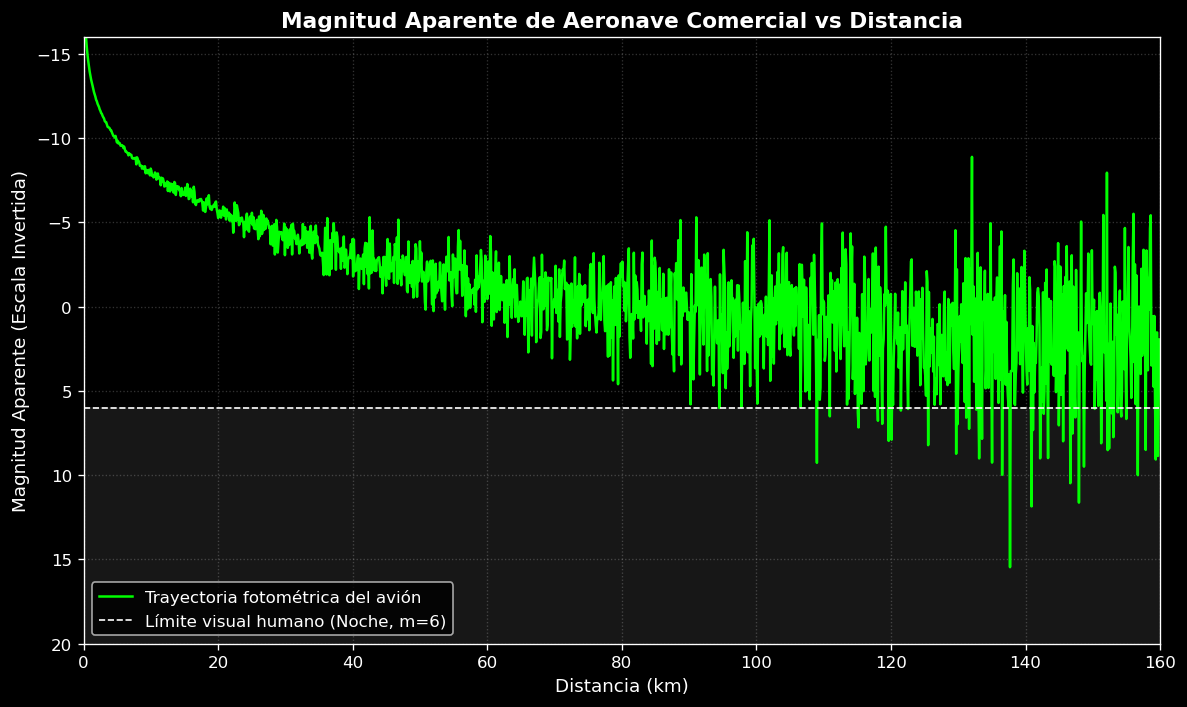

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---CONSTANTES FÍSICAS ---
radio_Tierra_m = 6371.0       # Radio terrestre (km)
H_observador_m = 1.70         # Altura de los ojos del observador (m)
c_zero_point = 14.18          # Calibración Lux (Magnitud)

def generar_curva_fotometrica(I0_log=6.0, visibilidad=40.0, color_nm=550, turbulencia=True, pitch=True):
    """
    Calcula la magnitud aparente de un avión en aproximación basándose 
    en la física atmosférica, dispersión de fotones y efectos de difracción.
    """
    # CONFIGURACIÓN DEL ESPACIO LOG
    I0 = 10**I0_log # Convertir log a intensidad lineal
    distancias_m = np.linspace(160000, 50, 1500) # Vector de 160 km a 50 m
    d_km = distancias_m / 1000.0

    # HORIZONTE GEOMÉTRICO
    slider_theta = np.radians(3.0) # Ángulo de planeo estándar (3 grados)
    h_avion_m = distancias_m * np.sin(slider_theta)

    horizonte_km = (np.sqrt(2 * radio_Tierra_m * (H_observador_m / 1000.0)) +
                    np.sqrt(2 * radio_Tierra_m * (h_avion_m / 1000.0)))
    
    # Máscara booleana para oclusión física por la curvatura de la Tierra
    es_visible_geo = d_km < horizonte_km 

    # DINÁMICA DE LA FUENTE (PITCH EFFECT)
    I_eff = I0
    if pitch: 
        desv_max = np.radians(4.0) 
        # La desviación disminuye geométricamente con la distancia
        desviacion = np.maximum(desv_max * (1 - (distancias_m / 60000.0)), 0) 
        sigma_haz = np.radians(5.0) 
        # Caída direccional Gaussiana del faro
        I_eff = I0 * np.exp(- (desviacion**2) / (2 * sigma_haz**2))

    # EXTINCIÓN ATMOSFÉRICA
    # Dispersión de Rayleigh (gases moleculares)
    H_Rayleigh = 8000.0
    k_rayleigh = 0.012 * ((550.0 / color_nm)**4) / 1000.0
    
    # Dispersión de Mie (aerosoles y visibilidad)
    H_Mie = 2000.0
    k_mie = (3.912 / visibilidad) / 1000.0

    # Espesor Óptico (Tau) integrado en la trayectoria inclinada
    tau = ((k_rayleigh * H_Rayleigh + k_mie * H_Mie) / np.sin(slider_theta)) * \
          (1 - np.exp(-distancias_m * np.sin(slider_theta) / 3000.0))

    # FOTOMETRÍA Y MAGNITUD FINAL
    E_lux = (I_eff / (distancias_m**2 + 100.0)) * np.exp(-tau)
    magnitud = -2.5 * np.log10(np.maximum(E_lux, 1e-25)) - c_zero_point

    # TURBULENCIA (Scintillation)
    if turbulencia:
        np.random.seed(42) # Semilla fija para que la gráfica sea reproducible en GitHub
        ruido = np.random.normal(0, 0.15, size=len(magnitud)) * (d_km / 10.0)**1.2
        magnitud += ruido

    # Aplicar corte de horizonte
    magnitud[~es_visible_geo] = np.nan
    
    return d_km, magnitud

# --- GRÁFICA ---
# Ejecutamos el motor físico con los parámetros por defecto
d_km, mag = generar_curva_fotometrica()

# Configuración estética de la gráfica (Fondo oscuro astronómico)
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

# Trazar la curva fotométrica principal
ax.plot(d_km, mag, color='#00FF00', linewidth=1.5, label='Trayectoria fotométrica del avión')

# Línea de referencia del límite visual para el ojo humano desnudo
ax.axhline(y=6.0, color='white', linestyle='--', linewidth=1, label='Límite visual humano (Noche, m=6)')

# Sombreado de advertencia en la zona invisible
ax.axhspan(6.0, 35, color='#1a1a1a', alpha=0.9)

# Invertir el eje Y (Convención estándar en astrofísica)
ax.invert_yaxis()

# Límites de los ejes para enmarcar la acción
ax.set_xlim(0, 160)
ax.set_ylim(20, -16)

# Etiquetas, leyenda y título
ax.set_xlabel('Distancia (km)', fontsize=11)
ax.set_ylabel('Magnitud Aparente (Escala Invertida)', fontsize=11)
ax.set_title('Magnitud Aparente de Aeronave Comercial vs Distancia', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.2, linestyle=':')
ax.legend(loc='lower left')

# Ajustar márgenes automáticamente y renderizar
plt.tight_layout()
plt.show()